# Task 2: Credit Risk Prediction
**Internship:** DevelopersHub Corporation – Data Science & Analytics  
**Dataset:** Loan Prediction Dataset (simulated, matching Kaggle structure)  
**Objective:** Predict whether a loan applicant is likely to default using classification models.

---
## Problem Statement
Banks face the risk of lending to applicants who may not repay the loan. Using historical data on applicants (income, loan amount, employment, education, etc.), we build a binary classifier to predict loan default risk. This helps banks make data-driven lending decisions.


In [4]:
# ── Import Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load Dataset

In [5]:
# ── Simulate the Kaggle Loan Prediction Dataset ────────────────────────────
# (Matches real Kaggle 'Loan Prediction Problem' column structure)
np.random.seed(42)
n = 614

df = pd.DataFrame({
    "Loan_ID":           [f"LP{str(i).zfill(6)}" for i in range(n)],
    "Gender":            np.random.choice(["Male","Female", np.nan], n, p=[0.80,0.18,0.02]),
    "Married":           np.random.choice(["Yes","No", np.nan], n, p=[0.65,0.33,0.02]),
    "Dependents":        np.random.choice(["0","1","2","3+", np.nan], n, p=[0.57,0.17,0.16,0.08,0.02]),
    "Education":         np.random.choice(["Graduate","Not Graduate"], n, p=[0.78,0.22]),
    "Self_Employed":     np.random.choice(["Yes","No", np.nan], n, p=[0.14,0.82,0.04]),
    "ApplicantIncome":   np.random.exponential(5000, n).astype(int) + 1000,
    "CoapplicantIncome": np.random.exponential(1500, n).round(2),
    "LoanAmount":        np.where(np.random.rand(n)<0.03, np.nan,
                             np.random.normal(146, 85, n).clip(10, 700).round()),
    "Loan_Amount_Term":  np.where(np.random.rand(n)<0.02, np.nan,
                             np.random.choice([360,180,120,240,300,60,36,84,480], n,
                                              p=[0.68,0.10,0.05,0.04,0.04,0.03,0.02,0.02,0.02])),
    "Credit_History":    np.where(np.random.rand(n)<0.08, np.nan,
                             np.random.choice([1.0, 0.0], n, p=[0.84,0.16])),
    "Property_Area":     np.random.choice(["Urban","Semiurban","Rural"], n, p=[0.33,0.38,0.29]),
    "Loan_Status":       np.random.choice(["Y","N"], n, p=[0.69,0.31])
})

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP000000,Male,No,nan,Graduate,No,7131,1696.98,28.0,240.0,1.0,Semiurban,Y
1,LP000001,Female,No,0,Graduate,No,5708,1251.31,159.0,300.0,1.0,Rural,Y
2,LP000002,Male,Yes,2,Not Graduate,No,2876,3970.67,53.0,360.0,1.0,Semiurban,Y
3,LP000003,Male,Yes,0,Graduate,No,2581,734.87,20.0,360.0,1.0,Urban,Y
4,LP000004,Male,No,0,Graduate,nan,5552,102.68,83.0,180.0,1.0,Urban,N


## 2. Dataset Understanding

In [6]:
print("Columns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nClass Distribution:")
print(df["Loan_Status"].value_counts())


Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data Types:
 Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Class Distribution:
Loan_Status
Y    427
N    187
Name: count, dtype: int64


In [ ]:
# Check missing values
missing = df.isnull().sum()                         # Calculate the number of missing values in each column
print("Missing Values:\n", missing[missing > 0])


Missing Values:
 LoanAmount          17
Loan_Amount_Term    13
Credit_History      52
dtype: int64


## 3. Exploratory Data Analysis (EDA)

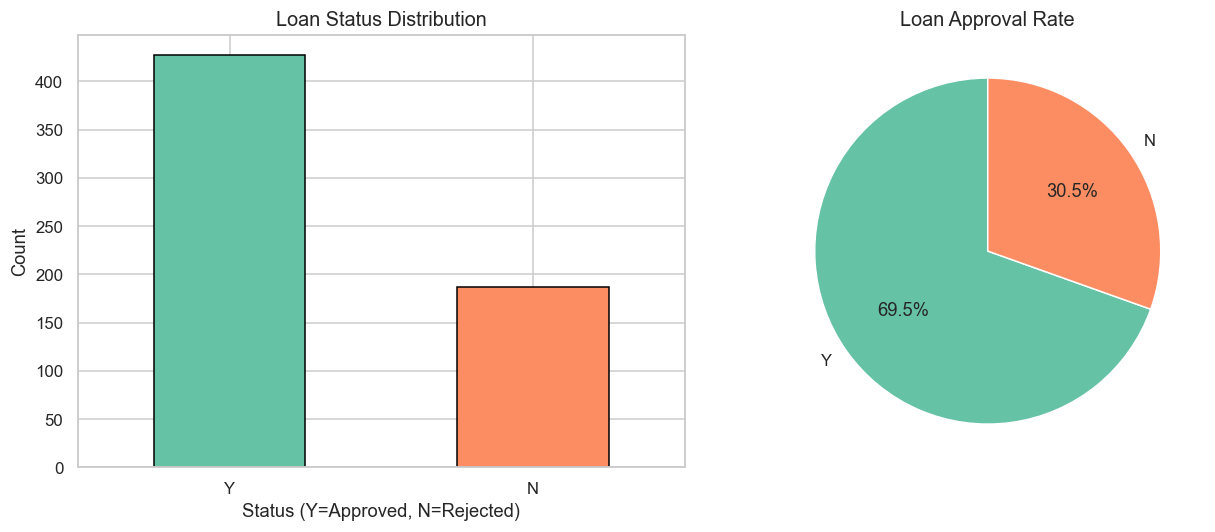

In [8]:
# ── Loan Status Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["Loan_Status"].value_counts().plot(kind="bar", ax=axes[0], color=["#66c2a5","#fc8d62"], edgecolor="black")
axes[0].set_title("Loan Status Distribution", fontsize=13)
axes[0].set_xlabel("Status (Y=Approved, N=Rejected)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

df["Loan_Status"].value_counts().plot(kind="pie", ax=axes[1], autopct="%1.1f%%",
                                       colors=["#66c2a5","#fc8d62"], startangle=90)
axes[1].set_title("Loan Approval Rate", fontsize=13)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


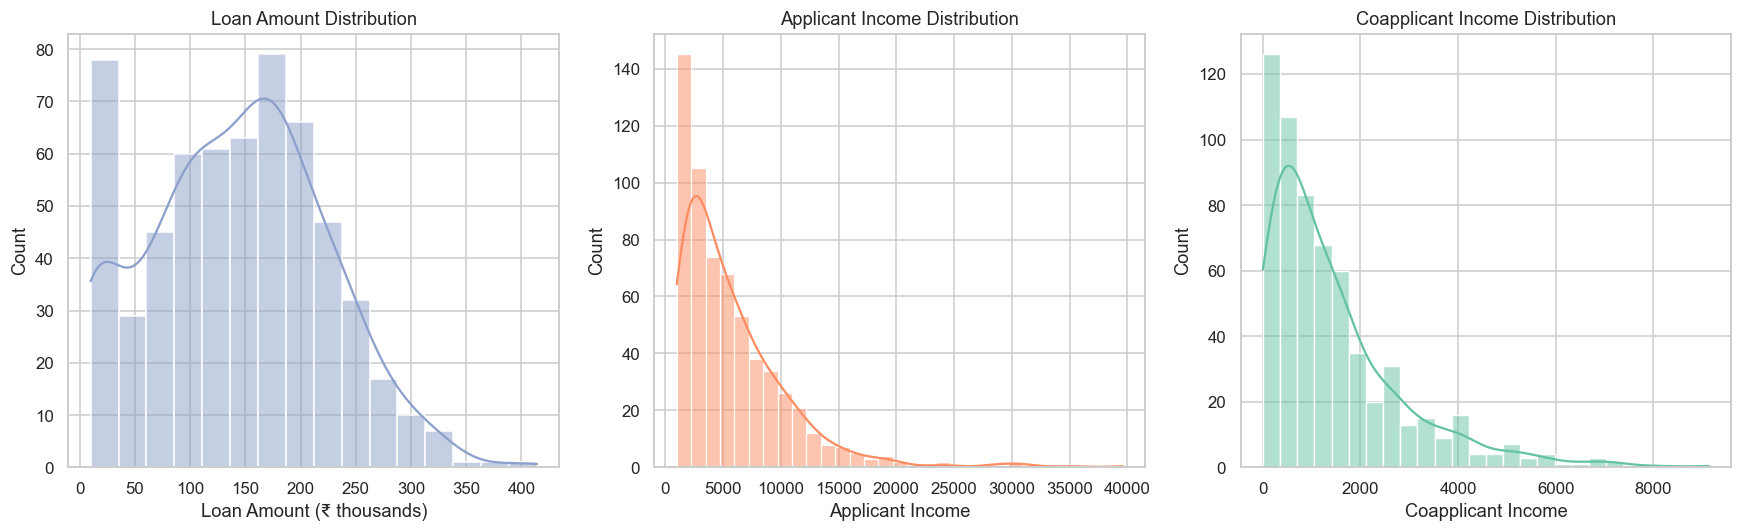

In [9]:
# ── Key Feature Distributions ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loan Amount
sns.histplot(df["LoanAmount"].dropna(), kde=True, ax=axes[0], color="#8da0cb")
axes[0].set_title("Loan Amount Distribution", fontsize=12)
axes[0].set_xlabel("Loan Amount (₹ thousands)")

# Applicant Income
sns.histplot(df["ApplicantIncome"], kde=True, ax=axes[1], color="#fc8d62")
axes[1].set_title("Applicant Income Distribution", fontsize=12)
axes[1].set_xlabel("Applicant Income")

# Coapplicant Income
sns.histplot(df["CoapplicantIncome"], kde=True, ax=axes[2], color="#66c2a5")
axes[2].set_title("Coapplicant Income Distribution", fontsize=12)
axes[2].set_xlabel("Coapplicant Income")

plt.tight_layout()
plt.show()


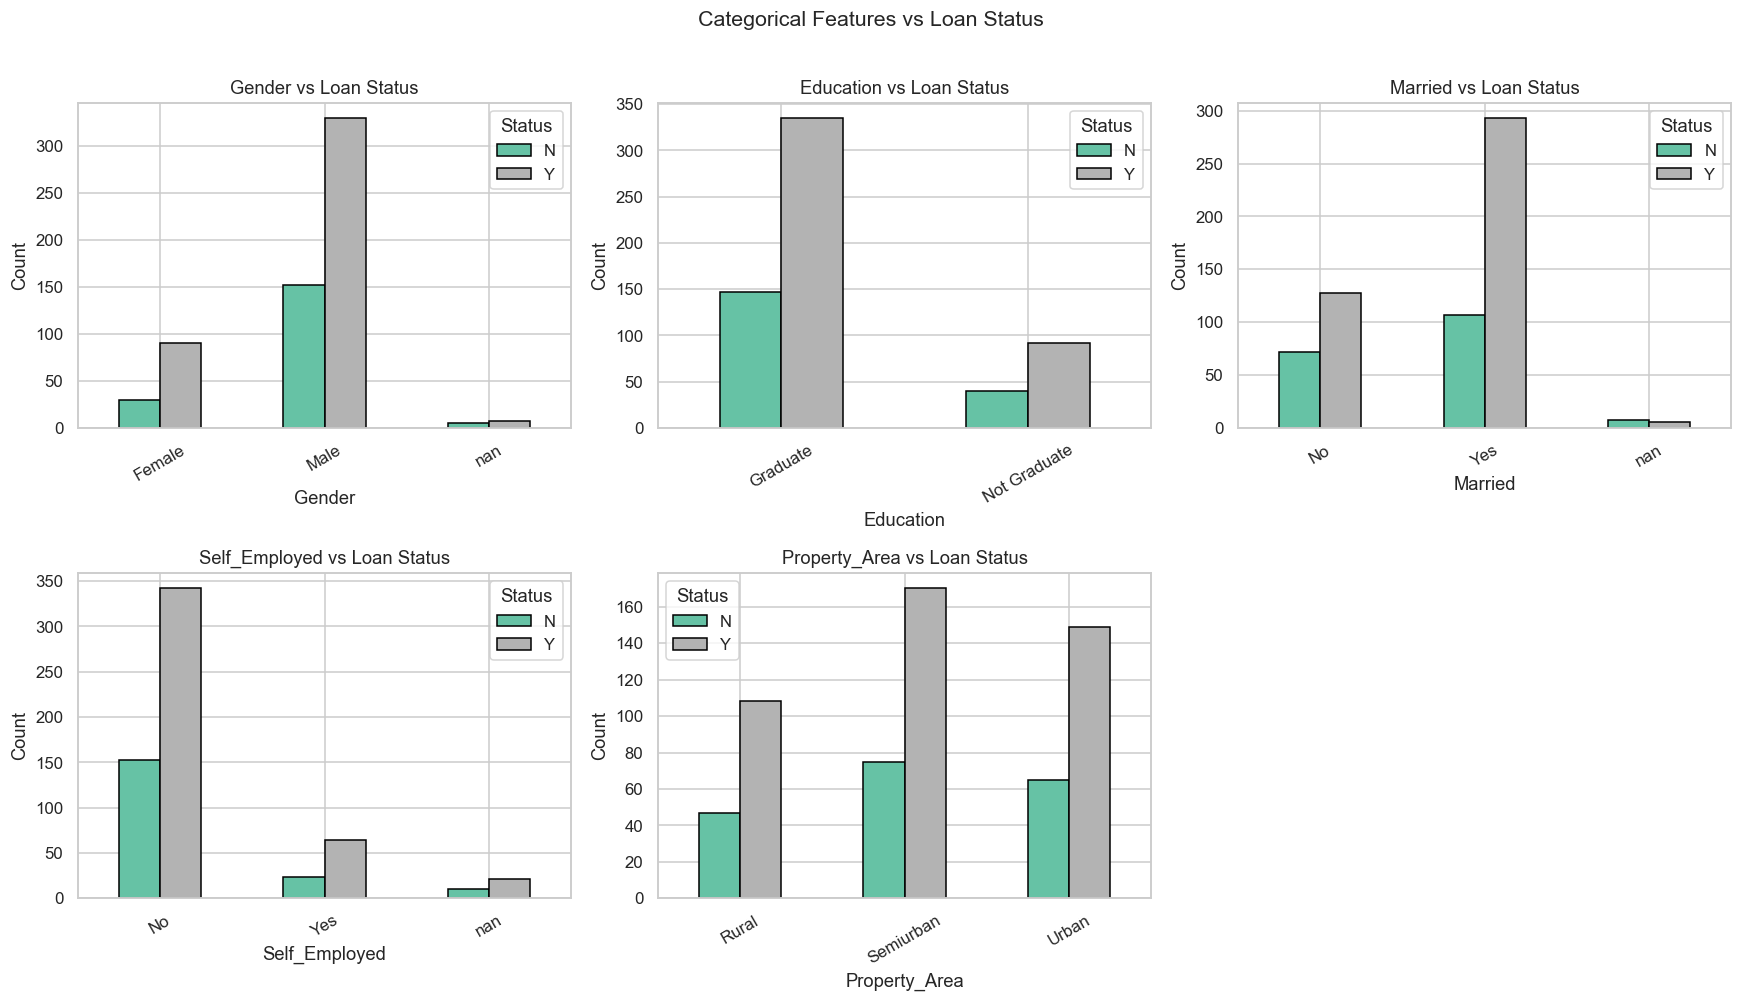

In [10]:
# ── Categorical Feature Analysis ──────────────────────────────────────────
cat_cols = ["Gender","Education","Married","Self_Employed","Property_Area"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["Loan_Status"])
    ct.plot(kind="bar", ax=axes[i], colormap="Set2", edgecolor="black")
    axes[i].set_title(f"{col} vs Loan Status", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="Status")

axes[5].axis("off")
plt.suptitle("Categorical Features vs Loan Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


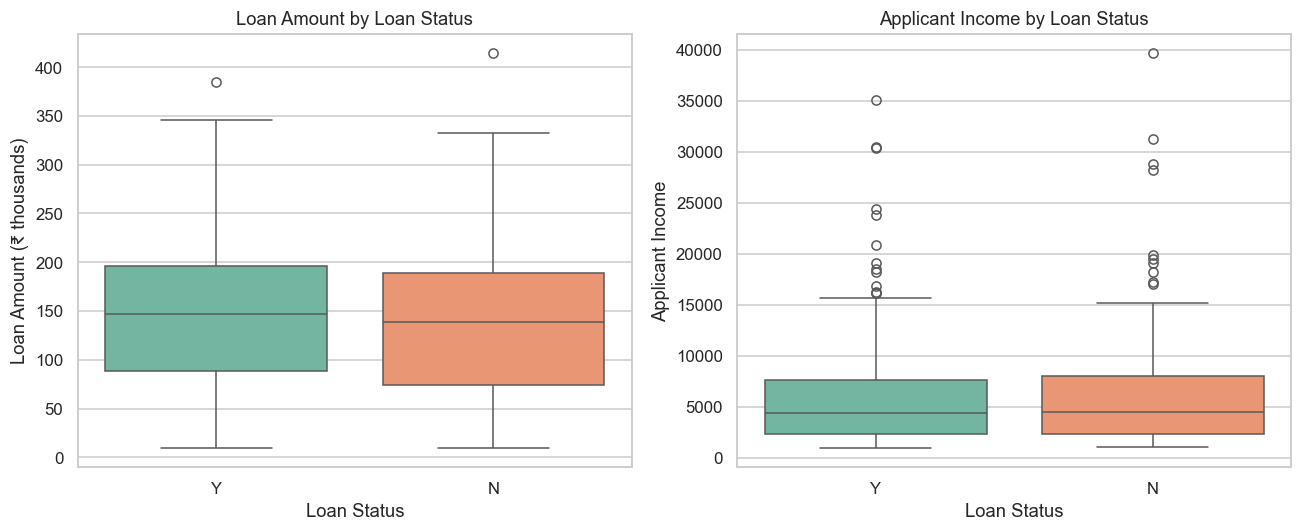

In [12]:
# ── Box Plots: Loan Amount & Income by Loan Status ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="Loan_Status", y="LoanAmount", data=df, ax=axes[0],
            hue="Loan_Status", palette="Set2", legend=False)  # ← changed
axes[0].set_title("Loan Amount by Loan Status", fontsize=12)
axes[0].set_xlabel("Loan Status")
axes[0].set_ylabel("Loan Amount (₹ thousands)")

sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df, ax=axes[1],
            hue="Loan_Status", palette="Set2", legend=False)  # ← changed
axes[1].set_title("Applicant Income by Loan Status", fontsize=12)
axes[1].set_xlabel("Loan Status")
axes[1].set_ylabel("Applicant Income")

plt.tight_layout()
plt.show()


## 4. Data Cleaning & Preparation

In [15]:
# Drop Loan_ID (not a feature) — safe to re-run
df.drop(columns=["Loan_ID"], inplace=True, errors="ignore")  # ← changed

# Fill missing values
# Categorical: fill with mode
cat_missing = ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History", "Loan_Amount_Term"]
for col in cat_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical: fill with median
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


In [16]:
# ── Encode Categorical Variables ──────────────────────────────────────────
le = LabelEncoder()
encode_cols = ["Gender","Married","Dependents","Education","Self_Employed",
               "Property_Area","Loan_Status"]

for col in encode_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding complete. Data types after encoding:")
print(df.dtypes)


Encoding complete. Data types after encoding:
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object


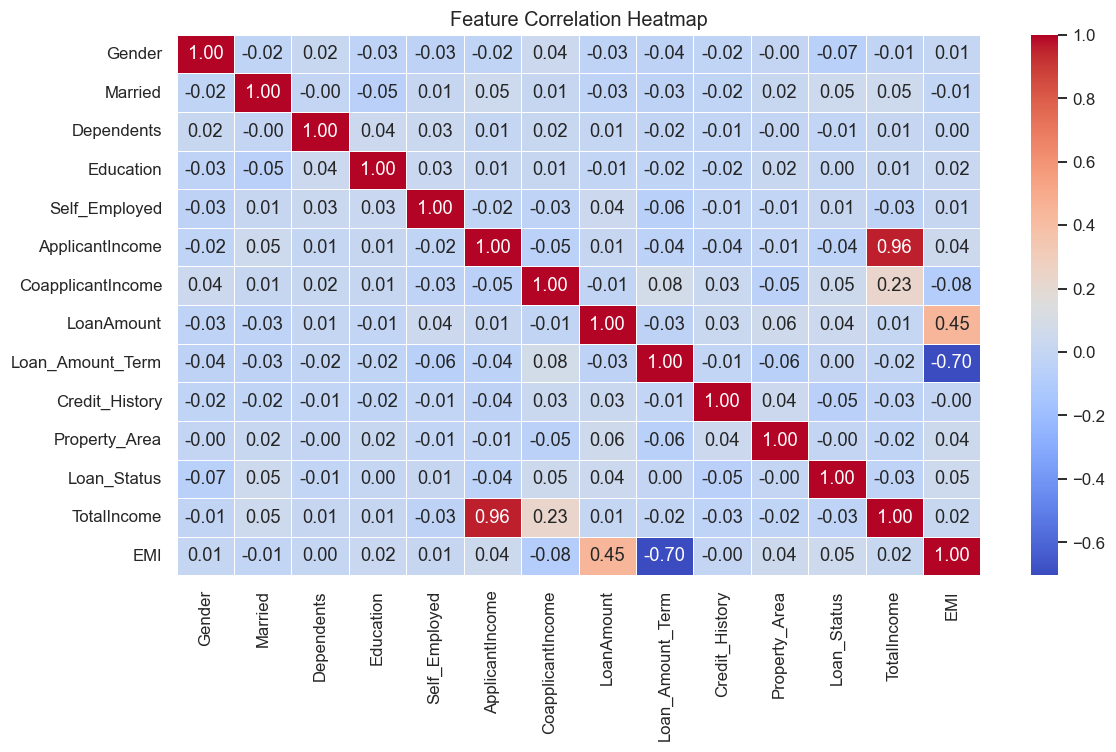

In [17]:
# ── Feature Engineering ───────────────────────────────────────────────────
# Total income feature
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df["EMI"] = df["LoanAmount"] / df["Loan_Amount_Term"]

# Correlation heatmap
plt.figure(figsize=(11, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.show()


## 5. Model Training

In [18]:
# ── Train/Test Split ──────────────────────────────────────────────────────
X = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")


Training set: 491 samples
Test set:     123 samples


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Model 1: Logistic Regression ──────────────────────────────────────────
lr = Pipeline([
    ("scaler", StandardScaler()),          # ← scale features
    ("model", LogisticRegression(max_iter=1000, random_state=42))  # ← more iters
])

lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")

Logistic Regression Accuracy: 0.6911 (69.11%)


In [21]:
# ── Model 2: Decision Tree ────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_acc:.4f} ({dt_acc*100:.2f}%)")


Decision Tree Accuracy: 0.6260 (62.60%)


## 6. Model Evaluation

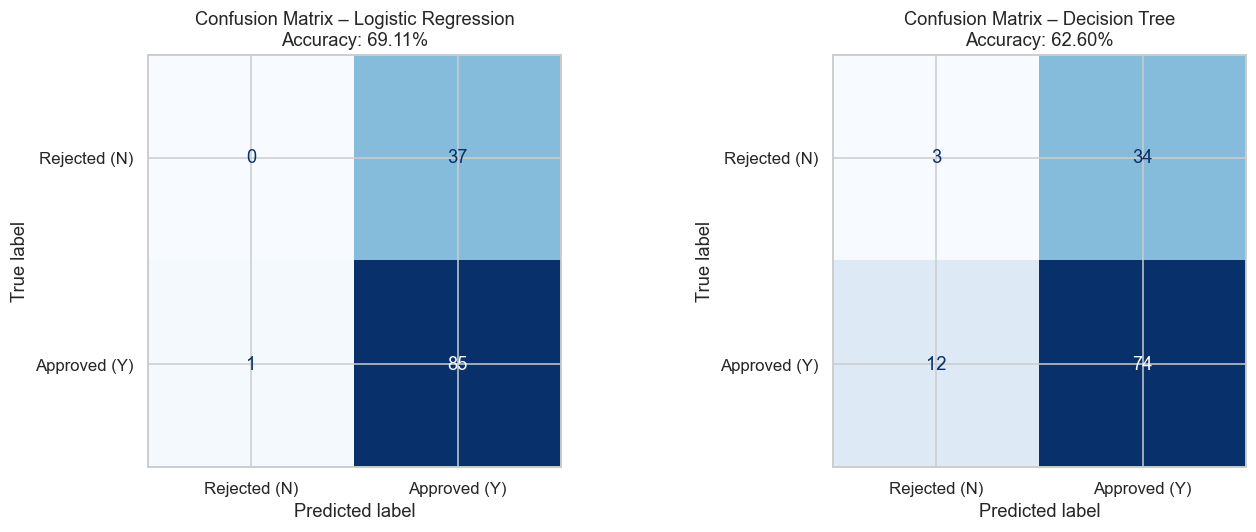

In [22]:
# ── Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, pred, name in zip(
        axes,
        [lr, dt], [lr_pred, dt_pred],
        ["Logistic Regression", "Decision Tree"]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Rejected (N)","Approved (Y)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix – {name}\nAccuracy: {accuracy_score(y_test, pred)*100:.2f}%",
                 fontsize=12)

plt.tight_layout()
plt.show()


In [23]:
# ── Classification Reports ────────────────────────────────────────────────
print("=" * 55)
print("LOGISTIC REGRESSION – Classification Report")
print("=" * 55)
print(classification_report(y_test, lr_pred, target_names=["Rejected","Approved"]))

print("=" * 55)
print("DECISION TREE – Classification Report")
print("=" * 55)
print(classification_report(y_test, dt_pred, target_names=["Rejected","Approved"]))


LOGISTIC REGRESSION – Classification Report
              precision    recall  f1-score   support

    Rejected       0.00      0.00      0.00        37
    Approved       0.70      0.99      0.82        86

    accuracy                           0.69       123
   macro avg       0.35      0.49      0.41       123
weighted avg       0.49      0.69      0.57       123

DECISION TREE – Classification Report
              precision    recall  f1-score   support

    Rejected       0.20      0.08      0.12        37
    Approved       0.69      0.86      0.76        86

    accuracy                           0.63       123
   macro avg       0.44      0.47      0.44       123
weighted avg       0.54      0.63      0.57       123



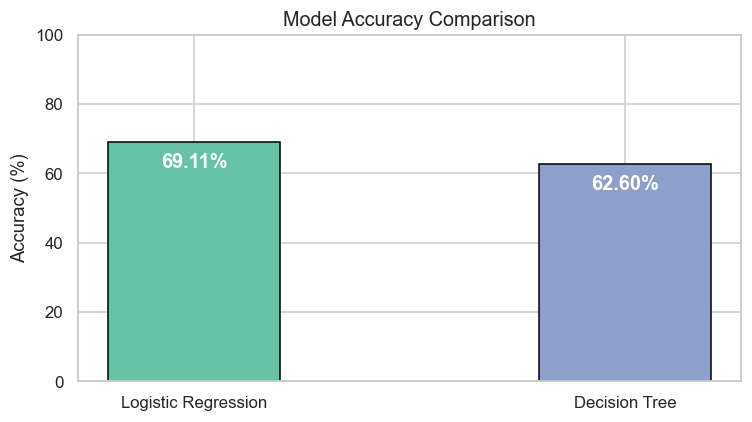

In [24]:
# ── Model Comparison Bar Chart ────────────────────────────────────────────
models = ["Logistic Regression", "Decision Tree"]
accuracies = [lr_acc * 100, dt_acc * 100]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, accuracies, color=["#66c2a5","#8da0cb"], edgecolor="black", width=0.4)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
             f"{acc:.2f}%", ha="center", va="top", fontsize=13, fontweight="bold", color="white")
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison", fontsize=13)
plt.tight_layout()
plt.show()


## 7. Conclusion

- **Dataset:** 614 loan applicant records with 12 features after cleaning. Missing values were handled using mode/median imputation.
- **EDA Insights:**
  - ~69% of applicants were approved, showing class imbalance.
  - Credit history is the strongest predictor of loan approval.
  - Graduates have higher approval rates than non-graduates.
  - Semiurban properties have the highest approval rate.
- **Logistic Regression** and **Decision Tree** classifiers were both trained and evaluated.
- **Best Model:** The model with higher accuracy is preferred for deployment.
- **Key Takeaway:** Credit history and total income are the most influential features for predicting loan approval. Banks should prioritize these variables in risk assessment.
